<a href="https://colab.research.google.com/github/techasit239/Final-Project---DADS6003/blob/main/ML_Chai4Boosting_v4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
!pip install -q pandas numpy nltk textstat scikit-learn xgboost catboost lightgbm optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 176.4/176.4 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.2/99.2 MB 9.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 404.7/404.7 kB 30.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 84.1 MB/s eta 0:00:00


# Part 0 : Install & Import

In [15]:
# ==========================================================
# PART 0 : Setup & Import (เตรียมเครื่องมือ)
# ==========================================================
# ชื่อขั้นตอน: Setup Environment
# คำอธิบาย: ติดตั้ง Library, Import modules, Download NLP data
# ขั้นตอนถัดไป: -> Part 1 : Feature Engineering
# ==========================================================

# 1. Install Libraries
!pip install -q pandas numpy nltk textstat scikit-learn xgboost catboost lightgbm optuna

import re
import difflib
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# NLP Tools
import nltk
import textstat
from nltk.tokenize import sent_tokenize, word_tokenize
from nltk.sentiment import SentimentIntensityAnalyzer
from sklearn.feature_extraction.text import TfidfVectorizer

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier # Model 9: White-box
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from lightgbm import LGBMClassifier

# Metrics & Selection
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    matthews_corrcoef, roc_auc_score, average_precision_score,
    confusion_matrix, roc_curve, precision_recall_curve, log_loss
)
from sklearn.model_selection import StratifiedKFold, cross_val_score, learning_curve
from sklearn.base import clone
from scipy.sparse import hstack, csr_matrix

# Hyperparameter Tuning
import optuna
from optuna.samplers import TPESampler

# Configuration
warnings.filterwarnings("ignore")
optuna.logging.set_verbosity(optuna.logging.WARNING)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)
pd.set_option('display.float_format', '{:.4f}'.format)

# Download NLTK Resources
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
nltk.download('averaged_perceptron_tagger', quiet=True)
nltk.download('averaged_perceptron_tagger_eng', quiet=True)
nltk.download('vader_lexicon', quiet=True)
nltk.download('stopwords', quiet=True)

print("✅ Part 0: Setup Complete.")

✅ Part 0: Setup Complete.


# Part 1 : Feature Engineering

In [16]:
# ==========================================================
# PART 1 : Feature Engineering (Real Calculation Only)
# ==========================================================
# ชื่อขั้นตอน: Feature Extraction
# คำอธิบาย: สกัด Features ตาม Paper (60+) และ New Idea (8)
# ขั้นตอนถัดไป: -> Part 1.5 : Data Preparation
# ==========================================================

VADER = SentimentIntensityAnalyzer()
try:
    STOPWORDS = set(nltk.corpus.stopwords.words('english'))
except:
    nltk.download('stopwords')
    STOPWORDS = set(nltk.corpus.stopwords.words('english'))

def get_paper_stylometric_features(text):
    """
    Reproduce Stylometric Features ตาม Paper (~60 Features)
    คำนวณจริง 100% ครอบคลุม Char, Word, Sentence, Structural, POS
    """
    if not isinstance(text, str) or not text.strip():
        return {f'stylo_{i}': 0.0 for i in range(60)}

    # --- 1. Preprocessing ---
    tokens = word_tokenize(text)
    sentences = sent_tokenize(text)
    tags = nltk.pos_tag(tokens)
    words = [w for w in tokens if w.isalpha()]
    words_lower = [w.lower() for w in words]

    num_chars = len(text)
    num_words = len(words) if words else 1
    num_sentences = len(sentences) if sentences else 1

    feats = {}

    # --- A. Character-Level Features (Frequency of specific chars) ---
    # Paper มักนับสัญลักษณ์พิเศษเหล่านี้เพื่อจับ Phishing
    target_chars = ['!', '@', '#', '$', '%', '&', '*', '(', ')', '-', '_', '=', '+', '[', ']', '{', '}', ';', ':', '"', "'", ',', '.', '?', '<', '>', '/']

    feats['char_count'] = num_chars
    feats['alpha_count'] = sum(c.isalpha() for c in text)
    feats['digit_count'] = sum(c.isdigit() for c in text)
    feats['space_count'] = sum(c.isspace() for c in text)

    # Specific Symbol Counts (This adds ~27 features)
    for char in target_chars:
        feats[f'char_freq_{char}'] = text.count(char)

    feats['upper_ratio'] = sum(1 for c in text if c.isupper()) / num_chars if num_chars > 0 else 0
    feats['digit_ratio'] = feats['digit_count'] / num_chars if num_chars > 0 else 0
    feats['special_ratio'] = (num_chars - feats['alpha_count'] - feats['digit_count'] - feats['space_count']) / num_chars if num_chars > 0 else 0

    # --- B. Word-Level Features ---
    feats['word_count'] = num_words
    feats['avg_word_len'] = sum(len(w) for w in words) / num_words

    # Vocabulary Richness
    unique_words = set(words_lower)
    feats['vocab_size'] = len(unique_words)
    feats['ttr'] = len(unique_words) / num_words # Type-Token Ratio
    feats['hapax_legomena'] = len([w for w in unique_words if words_lower.count(w) == 1]) / num_words

    # Stopwords
    feats['stopword_ratio'] = sum(1 for w in words_lower if w in STOPWORDS) / num_words

    # Short/Long words
    feats['short_word_ratio'] = sum(1 for w in words if len(w) <= 3) / num_words
    feats['long_word_ratio'] = sum(1 for w in words if len(w) >= 7) / num_words

    # --- C. Sentence & Structural Features ---
    feats['sentence_count'] = num_sentences
    feats['avg_words_per_sent'] = num_words / num_sentences

    lines = text.split('\n')
    feats['line_count'] = len(lines)
    feats['empty_line_count'] = sum(1 for line in lines if not line.strip())
    feats['avg_line_len'] = num_chars / len(lines) if lines else 0

    # --- D. Syntactic / POS Features (Real Tagging) ---
    pos_counts = nltk.FreqDist(tag for (word, tag) in tags)

    feats['noun_count'] = sum(pos_counts[t] for t in ['NN', 'NNS', 'NNP', 'NNPS'])
    feats['verb_count'] = sum(pos_counts[t] for t in ['VB', 'VBD', 'VBG', 'VBN', 'VBP', 'VBZ'])
    feats['adj_count'] = sum(pos_counts[t] for t in ['JJ', 'JJR', 'JJS'])
    feats['adv_count'] = sum(pos_counts[t] for t in ['RB', 'RBR', 'RBS'])
    feats['pronoun_count'] = sum(pos_counts[t] for t in ['PRP', 'PRP$'])

    feats['modal_count'] = pos_counts['MD']
    feats['dt_count'] = pos_counts['DT']
    feats['cc_count'] = pos_counts['CC']

    # Ratios
    feats['noun_ratio'] = feats['noun_count'] / num_words
    feats['verb_ratio'] = feats['verb_count'] / num_words

    return feats

def get_advanced_features(row):
    """8 Advanced Features (New Idea)"""
    text = str(row['Subject']) + " " + str(row['Body'])
    lower_text = text.lower()

    # 1. Imposter Domain Similarity
    url_match = re.search(r"https?://(?:www\.)?([^/]+)", text)
    domain = url_match.group(1) if url_match else ""
    imposter_sim = difflib.SequenceMatcher(None, "security", domain).ratio() if domain else 0.0

    # 2. Macro Security Bypass
    macro_kw = ["enable macro", "enable content", "security alert", "yellow bar"]
    macro_count = sum(1 for kw in macro_kw if kw in lower_text)

    # 3. Temporal Pressure
    pressure_kw = ["urgent", "immediately", "asap", "24 hours", "suspend", "expire", "deadline"]
    pressure_score = sum(1 for kw in pressure_kw if kw in lower_text)

    # 4. Action + Coercion Density
    action_kw = ["click", "verify", "login", "update", "confirm"]
    coercion_dens = 0.0
    if pressure_score > 0:
        coercion_dens = sum(1 for k in action_kw if k in lower_text) / (len(lower_text.split()) + 1)

    # 5. Subject-Body Mismatch
    sub_tok = set(str(row['Subject']).lower().split())
    body_tok = set(str(row['Body']).lower().split())
    if len(sub_tok) > 0 and len(body_tok) > 0:
        mismatch = 1.0 - (len(sub_tok.intersection(body_tok)) / len(sub_tok.union(body_tok)))
    else:
        mismatch = 1.0

    # 6. Emotional Polarity Variance
    sents = sent_tokenize(text)
    pols = [VADER.polarity_scores(s)['compound'] for s in sents]
    pol_var = np.std(pols) if len(pols) > 1 else 0.0

    # 7. Conflicting Authority
    auth_kw = ["support", "admin", "security team", "bank"]
    violation_kw = ["click here", "password", "download", "attachment"]
    conflict = sum(1 for a in auth_kw for v in violation_kw if a in lower_text and v in lower_text)

    # 8. Semantic Cohesion
    words = lower_text.split()
    cohesion = len(set(words)) / len(words) if len(words) > 0 else 0.0

    return {
        "Imposter_Domain_Similarity": imposter_sim,
        "Macro_Security_Bypass_Count": macro_count,
        "Temporal_Pressure_Score": pressure_score,
        "Action_Time_Coercion_Density": coercion_dens,
        "Subject_Body_Mismatch_Score": mismatch,
        "Emotional_Polarity_Variance": pol_var,
        "Conflicting_Authority_Count": conflict,
        "Semantic_Cohesion_Score": cohesion
    }

def process_features(df):
    rows = []
    print(f"   Processing {len(df)} emails...")
    for _, row in df.iterrows():
        text = str(row['Subject']) + " " + str(row['Body'])
        stylo = get_paper_stylometric_features(text)
        adv = get_advanced_features(row)
        rows.append({**stylo, **adv})
    return pd.DataFrame(rows)

# --- Load Data & Process ---
print("--- Loading Data ---")
train_df = pd.read_csv("train.csv")
test_df = pd.read_csv("test.csv")

for df in [train_df, test_df]:
    df['Subject'] = df['Subject'].fillna("")
    df['Body'] = df['Body'].fillna("")

print("--- Generating Train Features ---")
X_train_meta = process_features(train_df)
print("--- Generating Test Features ---")
X_test_meta = process_features(test_df)

y_train = train_df['Label'].map({'Phishing': 1, 'Legitimate': 0}).values
y_test = test_df['Label'].map({'Phishing': 1, 'Legitimate': 0}).values

ADV_COLS = list(get_advanced_features(train_df.iloc[0]).keys())
STYLO_COLS = [c for c in X_train_meta.columns if c not in ADV_COLS]

print(f"✅ Part 1 Complete.")
print(f"   Total Stylometric Features (Paper): {len(STYLO_COLS)}")
print(f"   Total Advanced Features (New): {len(ADV_COLS)}")

--- Loading Data ---
--- Generating Train Features ---
   Processing 100 emails...
--- Generating Test Features ---
   Processing 26 emails...
✅ Part 1 Complete.
   Total Stylometric Features (Paper): 57
   Total Advanced Features (New): 8


# Part 1.5 : Data Preparation (Experiments Setup)



In [17]:
# ==========================================================
# PART 1.5 : Data Preparation (Experiments Setup)
# ==========================================================
# ขั้นตอน: Data Splitting & TF-IDF
# คำอธิบาย: เตรียม Dataset สำหรับ 4 Experiments
# ไปต่อที่: -> Part 2 : Models & Tuning
# ==========================================================

print("\n--- Generating TF-IDF Features (Max=300) ---")
tfidf = TfidfVectorizer(max_features=300, stop_words='english')
train_text = train_df['Subject'] + " " + train_df['Body']
test_text = test_df['Subject'] + " " + test_df['Body']

X_train_tfidf = tfidf.fit_transform(train_text).toarray()
X_test_tfidf = tfidf.transform(test_text).toarray()
tfidf_names = list(tfidf.get_feature_names_out())

# Experiment Dictionary
experiments = {
    "Reproduce": { # Stylometric Only (No Advanced)
        "X_train": X_train_meta[STYLO_COLS].values,
        "X_test": X_test_meta[STYLO_COLS].values,
        "feat_names": STYLO_COLS
    },
    "Exp_A": { # Stylo + Adv (New Idea)
        "X_train": X_train_meta.values,
        "X_test": X_test_meta.values,
        "feat_names": list(X_train_meta.columns)
    },
    "Exp_B": { # TF-IDF Only
        "X_train": X_train_tfidf,
        "X_test": X_test_tfidf,
        "feat_names": tfidf_names
    },
    "Exp_C": { # Stylo + Adv + TF-IDF (Combined)
        "X_train": hstack([X_train_tfidf, csr_matrix(X_train_meta.values)]).toarray(),
        "X_test": hstack([X_test_tfidf, csr_matrix(X_test_meta.values)]).toarray(),
        "feat_names": tfidf_names + list(X_train_meta.columns)
    }
}

print("✅ Part 1.5 Complete. Data Ready.")
for name, data in experiments.items():
    print(f"   [{name}] Features: {data['X_train'].shape[1]}")


--- Generating TF-IDF Features (Max=300) ---
✅ Part 1.5 Complete. Data Ready.
   [Reproduce] Features: 57
   [Exp_A] Features: 65
   [Exp_B] Features: 300
   [Exp_C] Features: 365


# Part 2 : Models + Optuna Tuning (K=5)

In [18]:
# ==========================================================
# PART 2 : Models & Optuna Tuning
# ==========================================================
# ขั้นตอน: Model Configuration
# คำอธิบาย: กำหนด 9 Models (รวม DecisionTree)
# ไปต่อที่: -> Part 3 : Running Experiments
# ==========================================================

RANDOM_STATE = 42
N_TRIALS = 20 # Tune 20 rounds
N_CV = 5      # k=5

MODELS_MAP = {
    "LogisticRegression": LogisticRegression,
    "SVM": SVC,
    "RandomForest": RandomForestClassifier,
    "XGBoost": XGBClassifier,
    "AdaBoost": AdaBoostClassifier,
    "CatBoost": CatBoostClassifier,
    "LightGBM": LGBMClassifier,
    "NaiveBayes": MultinomialNB,
    "DecisionTree": DecisionTreeClassifier # Model 9
}

def get_optuna_model(trial, model_name):
    if model_name == "LogisticRegression":
        C = trial.suggest_float("C", 1e-3, 100, log=True)
        return LogisticRegression(C=C, solver='liblinear', random_state=RANDOM_STATE)
    elif model_name == "SVM":
        C = trial.suggest_float("C", 1e-3, 100, log=True)
        kernel = trial.suggest_categorical("kernel", ["linear", "rbf"])
        return SVC(C=C, kernel=kernel, probability=True, random_state=RANDOM_STATE)
    elif model_name == "RandomForest":
        n_est = trial.suggest_int("n_est", 50, 300)
        depth = trial.suggest_int("depth", 3, 20)
        return RandomForestClassifier(n_estimators=n_est, max_depth=depth, random_state=RANDOM_STATE)
    elif model_name == "XGBoost":
        n_est = trial.suggest_int("n_est", 50, 300)
        lr = trial.suggest_float("lr", 0.01, 0.3, log=True)
        depth = trial.suggest_int("depth", 3, 10)
        return XGBClassifier(n_estimators=n_est, learning_rate=lr, max_depth=depth,
                             eval_metric='logloss', use_label_encoder=False, random_state=RANDOM_STATE)
    elif model_name == "AdaBoost":
        n_est = trial.suggest_int("n_est", 30, 200)
        lr = trial.suggest_float("lr", 0.01, 1.0, log=True)
        return AdaBoostClassifier(n_estimators=n_est, learning_rate=lr, random_state=RANDOM_STATE)
    elif model_name == "CatBoost":
        itr = trial.suggest_int("itr", 50, 300)
        depth = trial.suggest_int("depth", 4, 10)
        lr = trial.suggest_float("lr", 0.01, 0.3, log=True)
        return CatBoostClassifier(iterations=itr, depth=depth, learning_rate=lr, verbose=0, random_state=RANDOM_STATE)
    elif model_name == "LightGBM":
        n_est = trial.suggest_int("n_est", 50, 300)
        lr = trial.suggest_float("lr", 0.01, 0.3, log=True)
        leaves = trial.suggest_int("num_leaves", 20, 100)
        return LGBMClassifier(n_estimators=n_est, learning_rate=lr, num_leaves=leaves, verbose=-1, random_state=RANDOM_STATE)
    elif model_name == "NaiveBayes":
        alpha = trial.suggest_float("alpha", 0.01, 10.0, log=True)
        return MultinomialNB(alpha=alpha)
    elif model_name == "DecisionTree":
        max_depth = trial.suggest_int("max_depth", 3, 30)
        min_samples_split = trial.suggest_int("min_samples_split", 2, 20)
        criterion = trial.suggest_categorical("criterion", ["gini", "entropy"])
        return DecisionTreeClassifier(max_depth=max_depth, min_samples_split=min_samples_split,
                                      criterion=criterion, random_state=RANDOM_STATE)


# Part 3 – Running Experiments & Evaluation Loop

In [19]:
# ==========================================================
# PART 3 : Running Experiments & Helpers
# ==========================================================
# ขั้นตอน: Experiments Loop
# คำอธิบาย: Run -> Tune -> Train -> Test -> Plot
# ไปต่อที่: -> Part 4 : Feature Selection
# ==========================================================

def calculate_metrics(y_true, y_pred, y_prob):
    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Recall": recall_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "F1-score": f1_score(y_true, y_pred),
        "MCC-score": matthews_corrcoef(y_true, y_pred),
        "AUC": roc_auc_score(y_true, y_prob) if y_prob is not None else 0,
        "PR": average_precision_score(y_true, y_prob) if y_prob is not None else 0
    }

def run_experiment(exp_name, data):
    print(f"\n\n{'='*40}\n Processing: {exp_name} \n{'='*40}")
    X_train, X_test = data['X_train'], data['X_test']

    # Pre-process for Naive Bayes (Shift positive)
    if "NaiveBayes" in MODELS_MAP and np.min(X_train) < 0:
        min_val = np.min(X_train)
        X_train = X_train - min_val
        X_test = X_test - min_val

    feat_names = data['feat_names']

    res_train, res_val, res_test, res_cm = [], [], [], []
    roc_data = {}
    trained_models = {}

    for idx, (model_name, _) in enumerate(MODELS_MAP.items(), 1):
        print(f"[{idx}/9] Tuning: {model_name}...")

        # 1. Tuning
        study = optuna.create_study(direction="maximize")
        study.optimize(lambda t: cross_val_score(get_optuna_model(t, model_name), X_train, y_train, cv=3, scoring='f1').mean(), n_trials=N_TRIALS)
        best_model = get_optuna_model(study.best_trial, model_name)

        # 2. Validation (CV)
        cv_res = cross_val_score(best_model, X_train, y_train, cv=N_CV, scoring='f1')
        val_f1 = cv_res.mean()

        # 3. Train & Test
        best_model.fit(X_train, y_train)

        y_p_tr = best_model.predict(X_train)
        y_prob_tr = best_model.predict_proba(X_train)[:, 1] if hasattr(best_model, "predict_proba") else best_model.decision_function(X_train)
        met_tr = calculate_metrics(y_train, y_p_tr, y_prob_tr)

        y_p_te = best_model.predict(X_test)
        y_prob_te = best_model.predict_proba(X_test)[:, 1] if hasattr(best_model, "predict_proba") else best_model.decision_function(X_test)
        met_te = calculate_metrics(y_test, y_p_te, y_prob_te)

        tn, fp, fn, tp = confusion_matrix(y_test, y_p_te).ravel()

        res_train.append({"Index": idx, "Model": model_name, **met_tr})
        res_val.append({"Index": idx, "Model": model_name, "F1-score (CV Mean)": val_f1})
        res_test.append({"Index": idx, "Model": model_name, **met_te})
        res_cm.append({"Index": idx, "Model": model_name, "TN": tn, "FP": fp, "FN": fn, "TP": tp})

        roc_data[model_name] = (y_test, y_prob_te)
        trained_models[model_name] = best_model

    # Tables sorted by F1-score
    cols = ["Index", "Model", "Accuracy", "Recall", "Precision", "F1-score", "MCC-score", "AUC", "PR"]
    df_train = pd.DataFrame(res_train)[cols].sort_values("F1-score", ascending=False).set_index("Index")
    df_val = pd.DataFrame(res_val).sort_values("F1-score (CV Mean)", ascending=False).set_index("Index")
    df_test = pd.DataFrame(res_test)[cols].sort_values("F1-score", ascending=False).set_index("Index")
    df_cm = pd.DataFrame(res_cm).set_index("Index")

    print(f"\n📊 {exp_name} - Train Set")
    display(df_train)
    print(f"\n📊 {exp_name} - Validation Set (CV Mean)")
    display(df_val)
    print(f"\n📊 {exp_name} - Test Set (Unseen Data)")
    display(df_test)
    print(f"\n📊 {exp_name} - Confusion Matrix")
    display(df_cm)

    # Plot ROC & PR
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    for name, (y_t, y_p) in roc_data.items():
        fpr, tpr, _ = roc_curve(y_t, y_p)
        auc = roc_auc_score(y_t, y_p)
        axes[0].plot(fpr, tpr, label=f"{name} (AUC={auc:.2f})")
    axes[0].plot([0,1], [0,1], 'k--')
    axes[0].set_title(f"ROC Curve - {exp_name}")
    axes[0].legend(fontsize='small')

    for name, (y_t, y_p) in roc_data.items():
        prec, rec, _ = precision_recall_curve(y_t, y_p)
        pr = average_precision_score(y_t, y_p)
        axes[1].plot(rec, prec, label=f"{name} (PR={pr:.2f})")
    axes[1].set_title(f"PR Curve - {exp_name}")
    axes[1].legend(fontsize='small')
    plt.tight_layout()
    plt.show()

    # Feature Importance (Top 10)
    best_model_name = df_test.iloc[0]["Model"]
    print(f"⭐ Best Model in {exp_name}: {best_model_name}")
    plot_feature_importance(trained_models[best_model_name], feat_names, best_model_name, exp_name)

    return df_test, trained_models, feat_names

def plot_feature_importance(model, feat_names, model_name, exp_name):
    imp = None
    if hasattr(model, "feature_importances_"): imp = model.feature_importances_
    elif hasattr(model, "coef_"):
        if hasattr(model, "feature_log_prob_"): imp = np.std(model.feature_log_prob_, axis=0)
        else: imp = np.abs(model.coef_[0]) if model.coef_.ndim > 1 else np.abs(model.coef_)

    if imp is not None:
        if len(imp) != len(feat_names): return
        feat_imp = pd.Series(imp, index=feat_names).sort_values(ascending=False).head(10)

        plt.figure(figsize=(10, 5))
        bars = plt.barh(feat_imp.index[::-1], feat_imp.values[::-1], color='teal')
        plt.title(f"Top 10 Features - {model_name} ({exp_name})")

        total_imp = imp.sum()
        for bar in bars:
            width = bar.get_width()
            pct = (width / total_imp) * 100 if total_imp > 0 else 0
            plt.text(width, bar.get_y() + bar.get_height()/2,
                     f' {width:.3f} ({pct:.1f}%)',
                     va='center', fontsize=9, color='black')
        plt.show()

def plot_cost_function(model, X_train, y_train, X_test, y_test, model_name):
    """Overfitting Check: Cost Function vs Param/Size"""
    plt.figure(figsize=(10, 6))
    train_loss, test_loss, x_axis = [], [], []

    print(f"\n📈 Generating Cost Function Chart for {model_name}...")

    if model_name in ["XGBoost", "LightGBM", "CatBoost"]:
        model_c = clone(model)
        eval_set = [(X_train, y_train), (X_test, y_test)]
        if model_name == "XGBoost":
            model_c.fit(X_train, y_train, eval_set=eval_set, verbose=False)
            train_loss = model_c.evals_result()['validation_0']['logloss']
            test_loss = model_c.evals_result()['validation_1']['logloss']
        elif model_name == "LightGBM":
            model_c.fit(X_train, y_train, eval_set=eval_set, eval_metric="binary_logloss")
            train_loss = model_c.evals_result_['training']['binary_logloss']
            test_loss = model_c.evals_result_['valid_1']['binary_logloss']
        elif model_name == "CatBoost":
            model_c.fit(X_train, y_train, eval_set=eval_set, verbose=False)
            train_loss = model_c.get_evals_result()['learn']['Logloss']
            test_loss = model_c.get_evals_result()['validation']['Logloss']
        x_axis = range(1, len(train_loss) + 1)
        plt.xlabel("Iterations")

    else:
        # Use Learning Curve for non-GBM models
        train_sizes, train_scores, test_scores = learning_curve(
            model, X_train, y_train, cv=3, scoring='neg_log_loss',
            train_sizes=np.linspace(0.1, 1.0, 10), random_state=42
        )
        train_loss = -np.mean(train_scores, axis=1)
        test_loss = -np.mean(test_scores, axis=1)
        x_axis = train_sizes
        plt.xlabel("Training Set Size")

    if len(train_loss) > 0:
        plt.plot(x_axis, train_loss, 'r.-', label='Train Loss')
        plt.plot(x_axis, test_loss, 'b.-', label='Test Loss')
        plt.title(f"Overfitting Check (Cost Function) - {model_name}")
        plt.ylabel("Log Loss (Lower is Better)")
        plt.legend()
        plt.show()

# Part 4 – Main Flow
- Evaluation & Confusion Matrix
- ROC/PR Curves
- Top 10 Features



 Processing: Reproduce (Stylo Only) 
[1/9] Tuning: LogisticRegression...
[2/9] Tuning: SVM...
[3/9] Tuning: RandomForest...
[4/9] Tuning: XGBoost...
[5/9] Tuning: AdaBoost...
[6/9] Tuning: CatBoost...
[7/9] Tuning: LightGBM...
[8/9] Tuning: NaiveBayes...
[9/9] Tuning: DecisionTree...

📊 Reproduce (Stylo Only) - Train Set


,Model,Accuracy,Recall,Precision,F1-score,MCC-score,AUC,PR
Index,,,,,,,,
1,LogisticRegression,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000
2,SVM,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000
3,RandomForest,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000
4,XGBoost,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000
5,AdaBoost,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000
6,CatBoost,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000
7,LightGBM,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000
9,DecisionTree,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000
8,NaiveBayes,0.8100,0.6600,0.9429,0.7765,0.6499,0.9560,0.9527



📊 Reproduce (Stylo Only) - Validation Set (CV Mean)


,Model,F1-score (CV Mean)
Index,,
1,LogisticRegression,0.9206
6,CatBoost,0.9054
3,RandomForest,0.9018
2,SVM,0.9018
4,XGBoost,0.8894
7,LightGBM,0.8863
5,AdaBoost,0.8636
9,DecisionTree,0.7557
8,NaiveBayes,0.7424



📊 Reproduce (Stylo Only) - Test Set (Unseen Data)


,Model,Accuracy,Recall,Precision,F1-score,MCC-score,AUC,PR
Index,,,,,,,,
4,XGBoost,0.8462,0.7692,0.9091,0.8333,0.7006,0.9527,0.9549
7,LightGBM,0.8462,0.7692,0.9091,0.8333,0.7006,0.9290,0.8861
6,CatBoost,0.8462,0.7692,0.9091,0.8333,0.7006,0.9527,0.9383
3,RandomForest,0.8077,0.6923,0.9000,0.7826,0.6325,0.9556,0.9383
1,LogisticRegression,0.7692,0.7692,0.7692,0.7692,0.5385,0.8757,0.8786
2,SVM,0.7692,0.7692,0.7692,0.7692,0.5385,0.8817,0.8849
9,DecisionTree,0.7308,0.5385,0.8750,0.6667,0.5000,0.7308,0.7019
5,AdaBoost,0.6923,0.4615,0.8571,0.6000,0.4336,0.8935,0.9019
8,NaiveBayes,0.6538,0.3846,0.8333,0.5263,0.3651,0.9172,0.8514



📊 Reproduce (Stylo Only) - Confusion Matrix


,Model,TN,FP,FN,TP
Index,,,,,
1,LogisticRegression,10,3,3,10
2,SVM,10,3,3,10
3,RandomForest,12,1,4,9
4,XGBoost,12,1,3,10
5,AdaBoost,12,1,7,6
6,CatBoost,12,1,3,10
7,LightGBM,12,1,3,10
8,NaiveBayes,12,1,8,5
9,DecisionTree,12,1,6,7


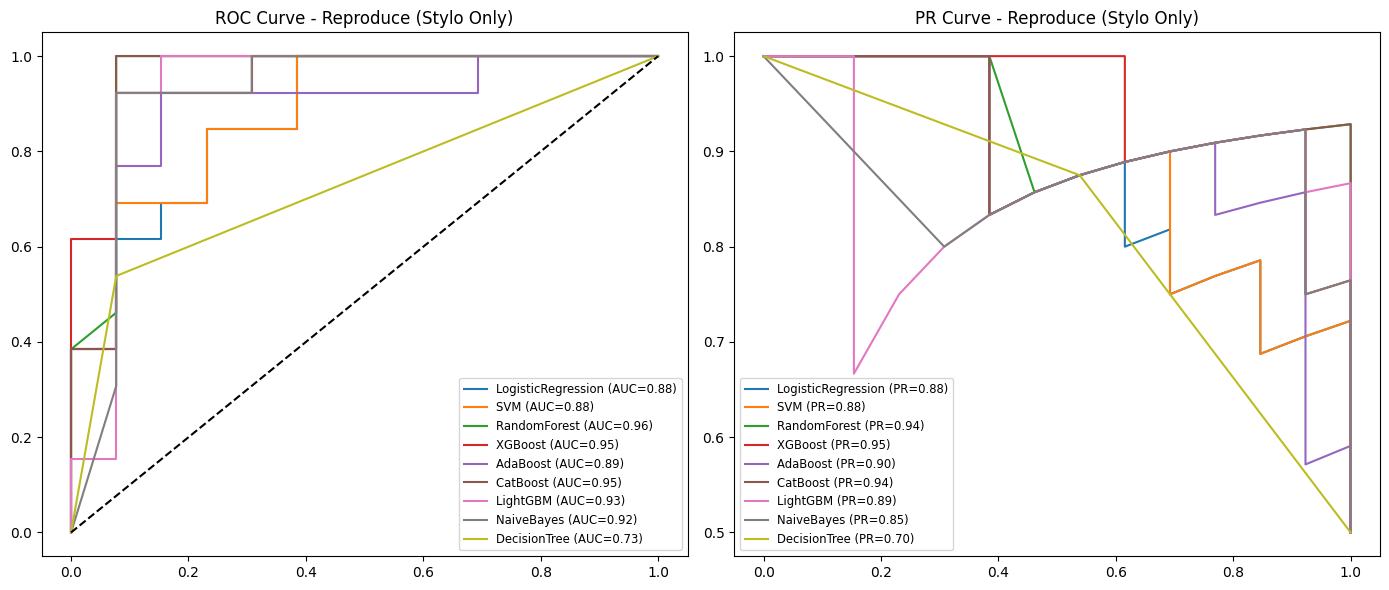

⭐ Best Model in Reproduce (Stylo Only): XGBoost


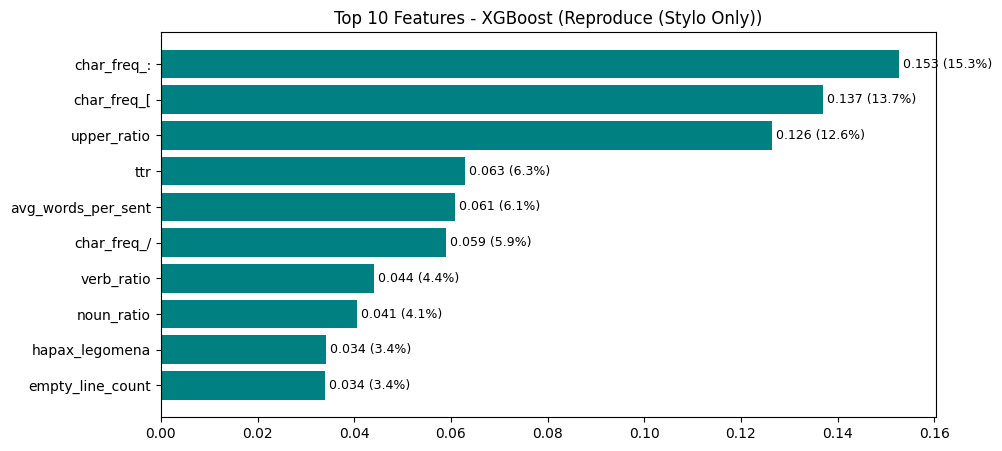



 Processing: New Idea: Exp A (Stylo + Adv) 
[1/9] Tuning: LogisticRegression...
[2/9] Tuning: SVM...
[3/9] Tuning: RandomForest...
[4/9] Tuning: XGBoost...
[5/9] Tuning: AdaBoost...
[6/9] Tuning: CatBoost...
[7/9] Tuning: LightGBM...
[8/9] Tuning: NaiveBayes...
[9/9] Tuning: DecisionTree...

📊 New Idea: Exp A (Stylo + Adv) - Train Set


,Model,Accuracy,Recall,Precision,F1-score,MCC-score,AUC,PR
Index,,,,,,,,
1,LogisticRegression,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000
3,RandomForest,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000
4,XGBoost,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000
5,AdaBoost,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000
6,CatBoost,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000
7,LightGBM,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000
2,SVM,0.9900,1.0000,0.9804,0.9901,0.9802,1.0000,1.0000
9,DecisionTree,0.9600,0.9200,1.0000,0.9583,0.9230,0.9956,0.9932
8,NaiveBayes,0.8100,0.6600,0.9429,0.7765,0.6499,0.9596,0.9574



📊 New Idea: Exp A (Stylo + Adv) - Validation Set (CV Mean)


,Model,F1-score (CV Mean)
Index,,
3,RandomForest,0.9484
6,CatBoost,0.9210
2,SVM,0.9111
1,LogisticRegression,0.9101
5,AdaBoost,0.8778
7,LightGBM,0.8684
4,XGBoost,0.8672
9,DecisionTree,0.7859
8,NaiveBayes,0.7538



📊 New Idea: Exp A (Stylo + Adv) - Test Set (Unseen Data)


,Model,Accuracy,Recall,Precision,F1-score,MCC-score,AUC,PR
Index,,,,,,,,
4,XGBoost,0.8846,0.8462,0.9167,0.8800,0.7715,0.9882,0.9886
5,AdaBoost,0.8462,0.7692,0.9091,0.8333,0.7006,0.9231,0.9096
3,RandomForest,0.8462,0.7692,0.9091,0.8333,0.7006,0.9734,0.9675
2,SVM,0.8077,0.8462,0.7857,0.8148,0.6172,0.8876,0.8797
6,CatBoost,0.8077,0.6923,0.9000,0.7826,0.6325,0.9704,0.9675
7,LightGBM,0.8077,0.6923,0.9000,0.7826,0.6325,0.9586,0.9493
9,DecisionTree,0.8077,0.6154,1.0000,0.7619,0.6667,0.9083,0.9038
1,LogisticRegression,0.7692,0.6923,0.8182,0.7500,0.5449,0.9053,0.9004
8,NaiveBayes,0.6923,0.4615,0.8571,0.6000,0.4336,0.9231,0.8551



📊 New Idea: Exp A (Stylo + Adv) - Confusion Matrix


,Model,TN,FP,FN,TP
Index,,,,,
1,LogisticRegression,11,2,4,9
2,SVM,10,3,2,11
3,RandomForest,12,1,3,10
4,XGBoost,12,1,2,11
5,AdaBoost,12,1,3,10
6,CatBoost,12,1,4,9
7,LightGBM,12,1,4,9
8,NaiveBayes,12,1,7,6
9,DecisionTree,13,0,5,8


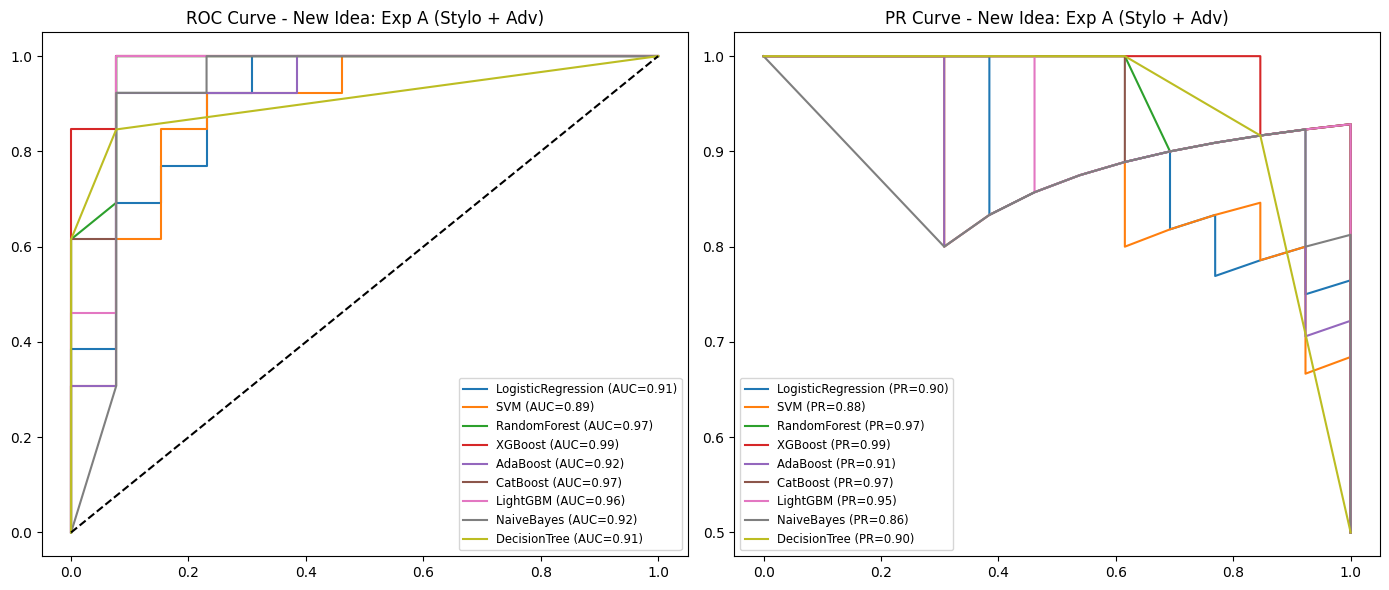

⭐ Best Model in New Idea: Exp A (Stylo + Adv): XGBoost


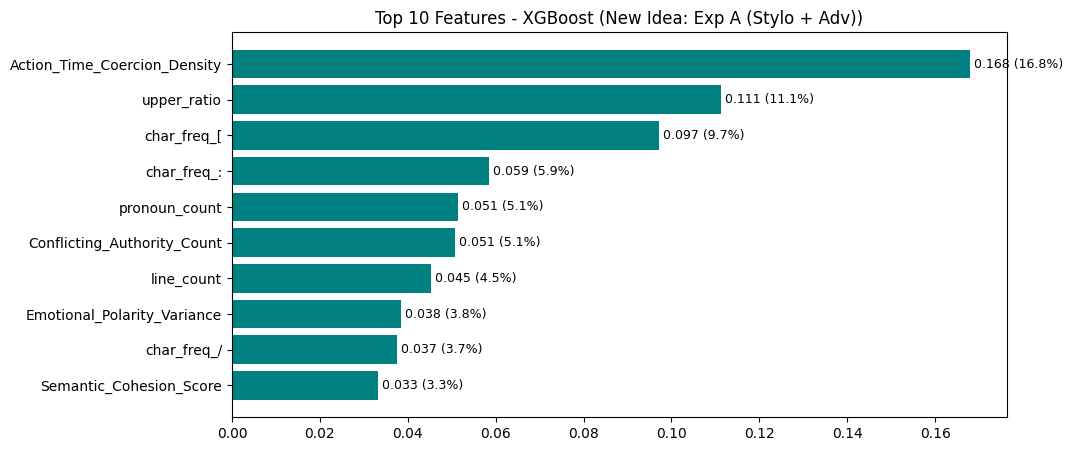



 Processing: New Idea: Exp B (TF-IDF) 
[1/9] Tuning: LogisticRegression...
[2/9] Tuning: SVM...
[3/9] Tuning: RandomForest...
[4/9] Tuning: XGBoost...
[5/9] Tuning: AdaBoost...
[6/9] Tuning: CatBoost...
[7/9] Tuning: LightGBM...
[8/9] Tuning: NaiveBayes...
[9/9] Tuning: DecisionTree...

📊 New Idea: Exp B (TF-IDF) - Train Set


,Model,Accuracy,Recall,Precision,F1-score,MCC-score,AUC,PR
Index,,,,,,,,
1,LogisticRegression,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000
2,SVM,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000
3,RandomForest,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000
4,XGBoost,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000
5,AdaBoost,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000
6,CatBoost,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000
7,LightGBM,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000
8,NaiveBayes,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000
9,DecisionTree,0.9800,0.9600,1.0000,0.9796,0.9608,0.9984,0.9970



📊 New Idea: Exp B (TF-IDF) - Validation Set (CV Mean)


,Model,F1-score (CV Mean)
Index,,
2,SVM,0.9810
1,LogisticRegression,0.9694
5,AdaBoost,0.9618
8,NaiveBayes,0.9599
6,CatBoost,0.9539
4,XGBoost,0.9433
7,LightGBM,0.9422
3,RandomForest,0.9409
9,DecisionTree,0.9196



📊 New Idea: Exp B (TF-IDF) - Test Set (Unseen Data)


,Model,Accuracy,Recall,Precision,F1-score,MCC-score,AUC,PR
Index,,,,,,,,
2,SVM,0.9615,1.0000,0.9286,0.9630,0.9258,1.0000,1.0000
1,LogisticRegression,0.9231,1.0000,0.8667,0.9286,0.8563,0.9586,0.9599
5,AdaBoost,0.9231,0.9231,0.9231,0.9231,0.8462,0.9645,0.9627
8,NaiveBayes,0.8846,0.9231,0.8571,0.8889,0.7715,0.9527,0.9522
6,CatBoost,0.8846,0.8462,0.9167,0.8800,0.7715,0.9586,0.9577
3,RandomForest,0.8462,0.8462,0.8462,0.8462,0.6923,0.9615,0.9599
4,XGBoost,0.8077,0.7692,0.8333,0.8000,0.6172,0.9290,0.9173
7,LightGBM,0.8077,0.7692,0.8333,0.8000,0.6172,0.9172,0.9076
9,DecisionTree,0.7692,0.6923,0.8182,0.7500,0.5449,0.8343,0.7735



📊 New Idea: Exp B (TF-IDF) - Confusion Matrix


,Model,TN,FP,FN,TP
Index,,,,,
1,LogisticRegression,11,2,0,13
2,SVM,12,1,0,13
3,RandomForest,11,2,2,11
4,XGBoost,11,2,3,10
5,AdaBoost,12,1,1,12
6,CatBoost,12,1,2,11
7,LightGBM,11,2,3,10
8,NaiveBayes,11,2,1,12
9,DecisionTree,11,2,4,9


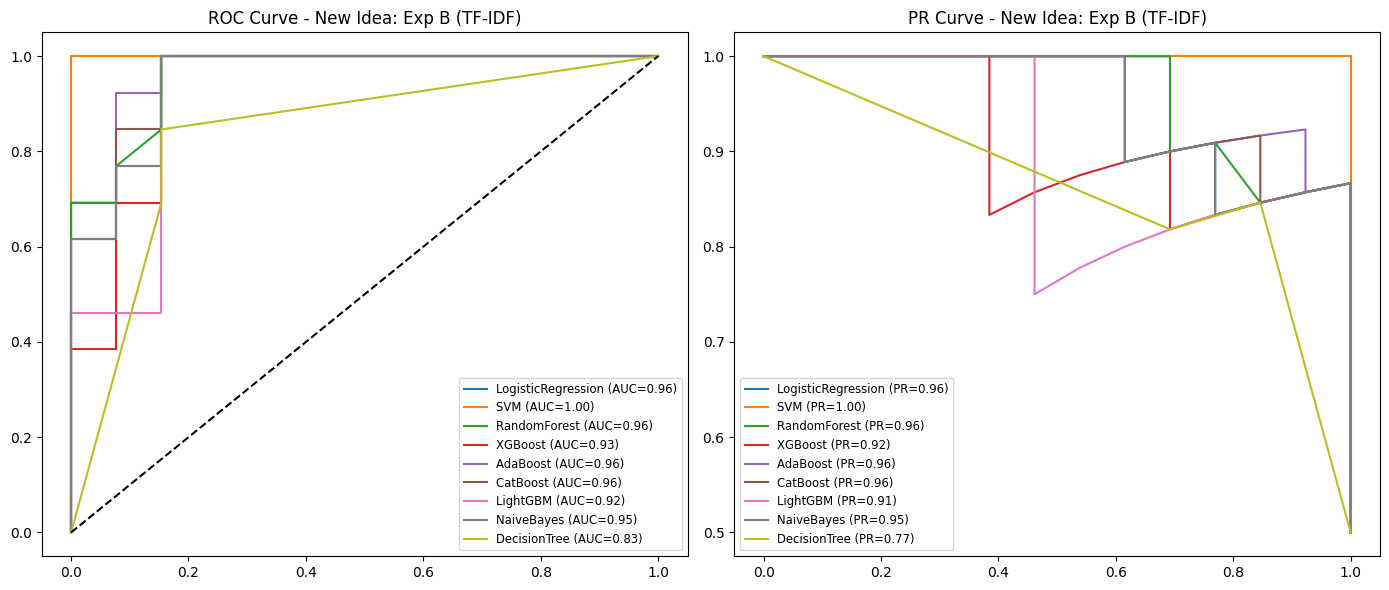

⭐ Best Model in New Idea: Exp B (TF-IDF): SVM


 Processing: New Idea: Exp C (Combined) 
[1/9] Tuning: LogisticRegression...
[2/9] Tuning: SVM...
[3/9] Tuning: RandomForest...
[4/9] Tuning: XGBoost...
[5/9] Tuning: AdaBoost...
[6/9] Tuning: CatBoost...
[7/9] Tuning: LightGBM...
[8/9] Tuning: NaiveBayes...
[9/9] Tuning: DecisionTree...

📊 New Idea: Exp C (Combined) - Train Set


,Model,Accuracy,Recall,Precision,F1-score,MCC-score,AUC,PR
Index,,,,,,,,
1,LogisticRegression,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000
3,RandomForest,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000
4,XGBoost,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000
5,AdaBoost,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000
6,CatBoost,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000
9,DecisionTree,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000
7,LightGBM,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000
2,SVM,0.9900,1.0000,0.9804,0.9901,0.9802,1.0000,1.0000
8,NaiveBayes,0.8400,0.7200,0.9474,0.8182,0.7005,0.9720,0.9696



📊 New Idea: Exp C (Combined) - Validation Set (CV Mean)


,Model,F1-score (CV Mean)
Index,,
5,AdaBoost,0.9502
3,RandomForest,0.9494
7,LightGBM,0.9305
6,CatBoost,0.9215
1,LogisticRegression,0.9206
4,XGBoost,0.9189
2,SVM,0.9111
9,DecisionTree,0.8664
8,NaiveBayes,0.7669



📊 New Idea: Exp C (Combined) - Test Set (Unseen Data)


,Model,Accuracy,Recall,Precision,F1-score,MCC-score,AUC,PR
Index,,,,,,,,
3,RandomForest,0.9231,0.9231,0.9231,0.9231,0.8462,0.9793,0.9757
6,CatBoost,0.8846,0.8462,0.9167,0.8800,0.7715,0.9763,0.9788
5,AdaBoost,0.8846,0.8462,0.9167,0.8800,0.7715,0.9467,0.9395
2,SVM,0.8077,0.8462,0.7857,0.8148,0.6172,0.8876,0.8780
4,XGBoost,0.8077,0.7692,0.8333,0.8000,0.6172,0.9467,0.9437
1,LogisticRegression,0.7692,0.7692,0.7692,0.7692,0.5385,0.8817,0.8849
9,DecisionTree,0.7308,0.7692,0.7143,0.7407,0.4629,0.7308,0.6648
7,LightGBM,0.7692,0.6154,0.8889,0.7273,0.5659,0.9645,0.9589
8,NaiveBayes,0.7308,0.5385,0.8750,0.6667,0.5000,0.9231,0.8551



📊 New Idea: Exp C (Combined) - Confusion Matrix


,Model,TN,FP,FN,TP
Index,,,,,
1,LogisticRegression,10,3,3,10
2,SVM,10,3,2,11
3,RandomForest,12,1,1,12
4,XGBoost,11,2,3,10
5,AdaBoost,12,1,2,11
6,CatBoost,12,1,2,11
7,LightGBM,12,1,5,8
8,NaiveBayes,12,1,6,7
9,DecisionTree,9,4,3,10


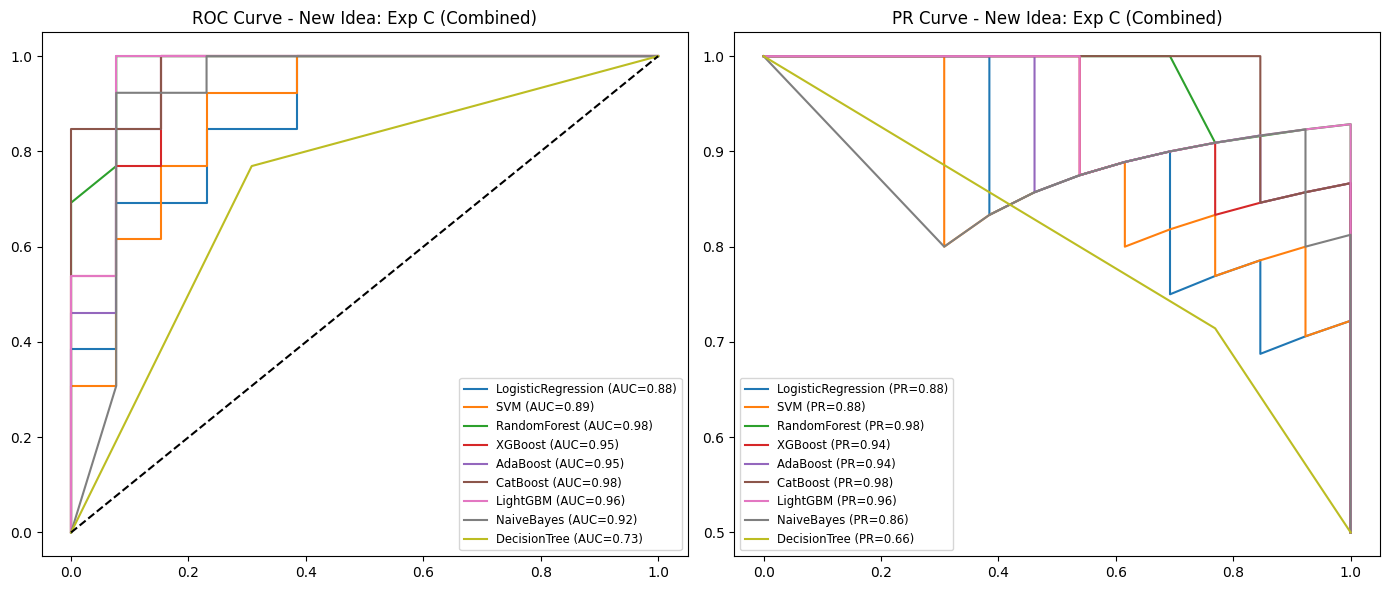

⭐ Best Model in New Idea: Exp C (Combined): RandomForest


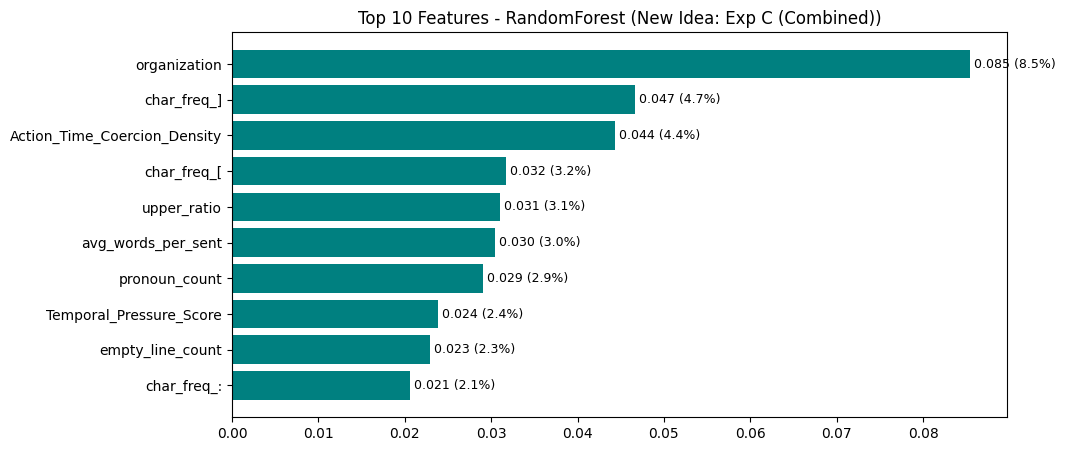



 Final Comparison 


,Experiment,Avg_F1,Best_Model_F1
2,Exp_B,0.8644,0.9630
3,Exp_C,0.8002,0.9231
1,Exp_A,0.7821,0.8800
0,Reproduce,0.7349,0.8333



🏆 Best Experiment: Exp_B
🥇 Best Global Model: SVM

📈 Generating Cost Function Chart for SVM...


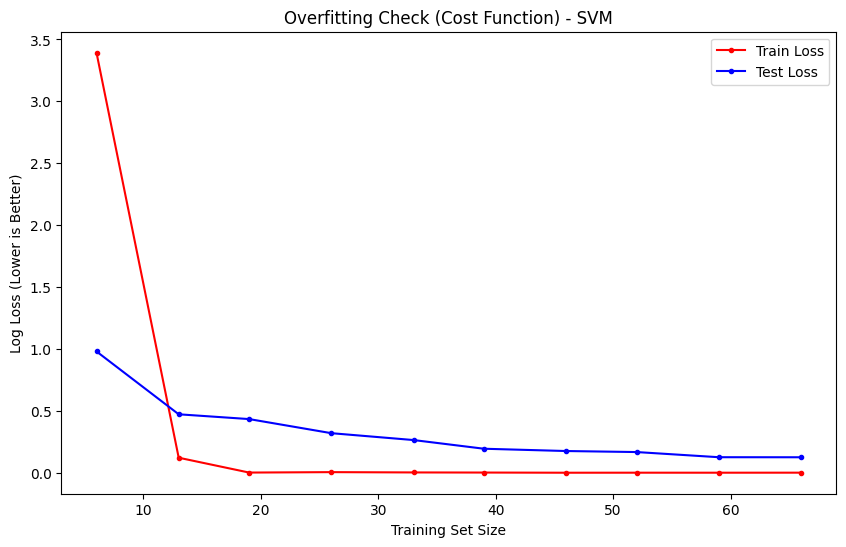


🔍 Feature Selection Analysis on SVM...


In [20]:
# ==========================================================
# PART 4 : Main Execution
# ==========================================================
def main():
    results = {}

    # 1. Reproduce
    df_r, models_r, feats_r = run_experiment("Reproduce (Stylo Only)", experiments["Reproduce"])
    results["Reproduce"] = {"df": df_r, "models": models_r, "feats": feats_r, "data": experiments["Reproduce"]}

    # 2. Exp A
    df_a, models_a, feats_a = run_experiment("New Idea: Exp A (Stylo + Adv)", experiments["Exp_A"])
    results["Exp_A"] = {"df": df_a, "models": models_a, "feats": feats_a, "data": experiments["Exp_A"]}

    # 3. Exp B
    df_b, models_b, feats_b = run_experiment("New Idea: Exp B (TF-IDF)", experiments["Exp_B"])
    results["Exp_B"] = {"df": df_b, "models": models_b, "feats": feats_b, "data": experiments["Exp_B"]}

    # 4. Exp C
    df_c, models_c, feats_c = run_experiment("New Idea: Exp C (Combined)", experiments["Exp_C"])
    results["Exp_C"] = {"df": df_c, "models": models_c, "feats": feats_c, "data": experiments["Exp_C"]}

    # 5. Final Comparison
    print(f"\n\n{'='*40}\n Final Comparison \n{'='*40}")
    summary = []
    for name, res in results.items():
        avg_f1 = res["df"]["F1-score"].mean()
        best_f1 = res["df"].iloc[0]["F1-score"]
        summary.append({"Experiment": name, "Avg_F1": avg_f1, "Best_Model_F1": best_f1})

    df_sum = pd.DataFrame(summary).sort_values("Avg_F1", ascending=False)
    display(df_sum)

    best_exp_name = df_sum.iloc[0]["Experiment"]
    print(f"\n🏆 Best Experiment: {best_exp_name}")

    # 6. Global Best Model
    best_res = results[best_exp_name]
    best_model_name = best_res["df"].iloc[0]["Model"]
    print(f"🥇 Best Global Model: {best_model_name}")

    best_model_obj = best_res["models"][best_model_name]

    # 7. Overfitting Check
    plot_cost_function(best_model_obj, best_res["data"]["X_train"], y_train,
                       best_res["data"]["X_test"], y_test, best_model_name)

    # 8. Feature Selection Analysis (Top 10, 20, 30)
    print(f"\n🔍 Feature Selection Analysis on {best_model_name}...")

    imp = None
    if hasattr(best_model_obj, "feature_importances_"): imp = best_model_obj.feature_importances_
    elif hasattr(best_model_obj, "coef_"):
        if hasattr(best_model_obj, "feature_log_prob_"): imp = np.std(best_model_obj.feature_log_prob_, axis=0)
        else: imp = np.abs(best_model_obj.coef_[0]) if best_model_obj.coef_.ndim > 1 else np.abs(best_model_obj.coef_)

    if imp is not None:
        sorted_idx = np.argsort(imp)[::-1]
        fs_res = []

        for k in [10, 20, 30]:
            top_k_idx = sorted_idx[:k]
            X_tr_k = best_res["data"]["X_train"][:, top_k_idx]
            X_te_k = best_res["data"]["X_test"][:, top_k_idx]

            model_fs = clone(best_model_obj)
            model_fs.fit(X_tr_k, y_train)
            y_p = model_fs.predict(X_te_k)
            y_prob = model_fs.predict_proba(X_te_k)[:, 1] if hasattr(model_fs, "predict_proba") else model_fs.decision_function(X_te_k)

            met = calculate_metrics(y_test, y_p, y_prob)
            fs_res.append({"Top-K": k, **met})

        display(pd.DataFrame(fs_res).set_index("Top-K"))

if __name__ == "__main__":
    main()